In [1]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [2]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [3]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.03]


t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 500

#paper
D_l = 6 #kpc
D_s = 8 #kpc

m1 = 0.3 #Lens Star Mass (Solar Mass)

In [4]:
def Einstein_Radius(M_solar, D_l_kpc, D_s_kpc):
    """
    Computes the Einstein Radius.

    Parameters:
    M_solar : float
        Mass of the lens in Solar masses
    D_l_kpc : float
        Distance to the lens in kpc
    D_s_kpc : float
        Distance to the source in kpc

    Returns:
    R_E : float
        Einstein radius in meters
    theta_E_arcsec : float
        Einstein radius in arcseconds
    theta_E_mas : float
        Einstein radius in milliarcseconds
    """
    # Constants
    c = 3e8            # speed of light in m/s
    G = 6.674e-11      # gravitational constant in N m^2 / kg^2
    M_sun = 1.989e30   # kg
    kpc_to_m = 3.086e19  # meters
    rad_to_arcsec = 206265  # arcsec per radian

    # Convert inputs
    M = M_solar * M_sun
    D_l = D_l_kpc * kpc_to_m
    D_s = D_s_kpc * kpc_to_m
    D_ls = D_s - D_l

    # Einstein radius in meters
    R_E = ((4 * G * M / c**2) * (D_ls * D_l / D_s)) ** 0.5

    # Angular Einstein radius in radians
    theta_E_rad = R_E / D_l

    # Convert to arcsec and mas
    theta_E_arcsec = theta_E_rad * rad_to_arcsec
    theta_E_mas = theta_E_arcsec * 1000

    return R_E, theta_E_arcsec, theta_E_mas

In [5]:
R_E, theta_E_arcsec, theta_E_mas = Einstein_Radius(m1, D_l, D_s)

print(f"Einstein Radius: {R_E:.2e} m")
print(f"Angular Einstein Radius: {theta_E_arcsec:.4f} arcsec")
print(f"Angular Einstein Radius: {theta_E_mas:.2f} mas")

Einstein Radius: 2.86e+11 m
Angular Einstein Radius: 0.0003 arcsec
Angular Einstein Radius: 0.32 mas


In [6]:
# Roman sensitivity in θE units
thetaE_mas = theta_E_mas
roman_sensitivity = 0.01 / thetaE_mas   # 10 µas = 0.01 mas
roman_sensitivity_3 = 0.003 / thetaE_mas   # 10 µas = 0.01 mas


In [7]:
#u0 values
u0_values = [-0.005, -0.010, -0.015, -0.020, -0.025, 
             -0.030, -0.035, -0.040, -0.045, -0.050]   

#parameters
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q2 + q3
t0 = 0
tE = 20
rho = 1.8e-3
rs  = rho
secnum   = 45
basenum  = 2
num_points = 1000
alpha_deg = 0


#storing results
results = {}

for u0 in u0_values:
    u0_list = [u0]

    triple_model = ThreeLens1S(
        t0, tE, rho, u0_list, q2, q3, s2, s3, alpha_deg, psi, rs,
        secnum, basenum, num_points
    )

    #double sim
    binary_model = TwoLens1S(
        t0, tE, rho, u0_list, q2, s2, alpha_deg, t_lc=triple_model.highres_t
    )

    t_hr   = triple_model.highres_t
    tau_hr = triple_model.highres_tau

    #systems
    bin_sys = binary_model.systems[0]
    tri_sys = triple_model.systems[0]

    def get_xy(sys, prefer='lc'):
        #returns (cent_x, cent_y, y1s, y2s)
        if prefer == 'lc' and all(k in sys for k in ('cent_x_lc','cent_y_lc','y1s_lc','y2s_lc')):
            return sys['cent_x_lc'], sys['cent_y_lc'], sys['y1s_lc'], sys['y2s_lc']
        #chatGPT fall backs
        elif all(k in sys for k in ('cent_x_hr','cent_y_hr','y1s_hr','y2s_hr')):
            return sys['cent_x_hr'], sys['cent_y_hr'], sys['y1s_hr'], sys['y2s_hr']
        else:
            return sys['cent_x'], sys['cent_y'], sys['y1s'], sys['y2s']

    b_cx, b_cy, b_y1, b_y2 = get_xy(bin_sys, prefer='lc')
    t_cx, t_cy, t_y1, t_y2 = get_xy(tri_sys, prefer='lc')

    #centroid
    dx_bin = b_cx - b_y1
    dy_bin = b_cy - b_y2

    dx_tri = t_cx - t_y1
    dy_tri = t_cy - t_y2

    dy_tri = -dy_tri
    

    delta_bin = np.sqrt(dx_bin**2 + dy_bin**2)
    delta_tri = np.sqrt(dx_tri**2 + dy_tri**2)
    delta_tri = delta_tri[::-1]

    # residuals
    res = (delta_bin - delta_tri)

    #store results
    results[u0] = dict(
        tau=tau_hr,
        dx_tri=dx_tri, dy_tri=dy_tri, delta_tri=delta_tri,
        dx_bin=dx_bin, dy_bin=dy_bin, delta_bin=delta_bin,
        res=res
    )

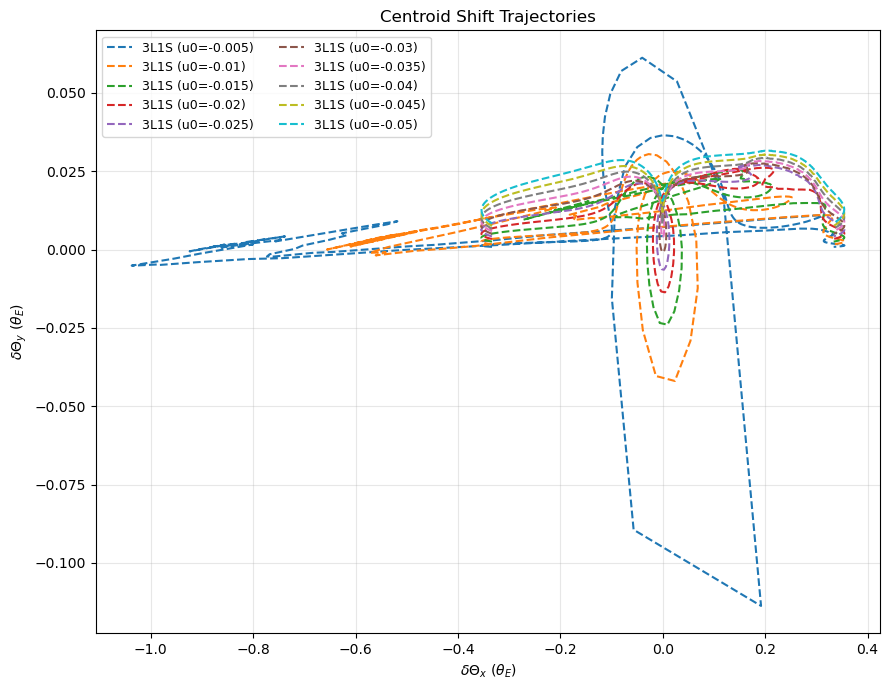

In [18]:
# 1)centroid trajectories per u0
plt.figure(figsize=(9,7))
for u0, R in results.items():
    #plt.plot(R['dx_bin'], R['dy_bin'],  '-',  label=fr'2L1S (u0={u0:g})')
    plt.plot(R['dx_tri'], R['dy_tri'], '--',  label=fr'3L1S (u0={u0:g})')
plt.xlabel(r'$\delta \Theta_x\ (\theta_E)$')
plt.ylabel(r'$\delta \Theta_y\ (\theta_E)$')
plt.title('Centroid Shift Trajectories')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

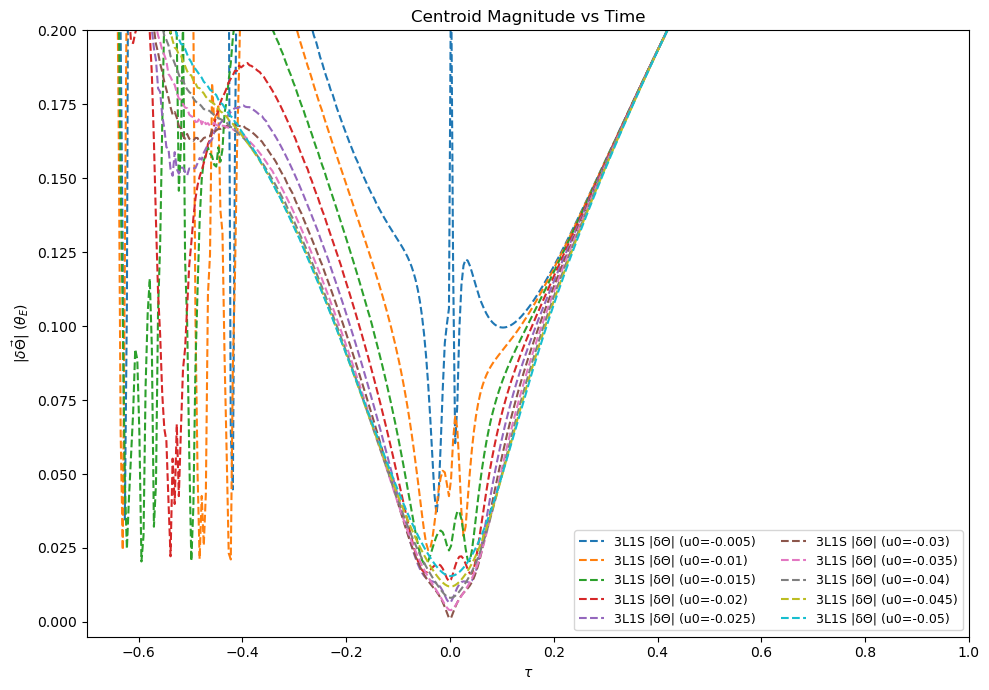

In [9]:
# |δΘ| vs τ
plt.figure(figsize=(10,7))
for u0, R in results.items():
    #plt.plot(R['tau'], R['delta_bin'],  '-',  label=fr'2L1S |δΘ| (u0={u0:g})')
    plt.plot(R['tau'], R['delta_tri'], '--',  label=fr'3L1S |δΘ| (u0={u0:g})')

plt.xlabel(r'$\tau$')
plt.ylabel(r'$|\delta \vec{\Theta}| \ (\theta_E)$')

plt.xlim(-0.7, 1)
plt.ylim(-0.005, 0.2)
plt.title('Centroid Magnitude vs Time')
plt.legend(loc = 'lower right', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

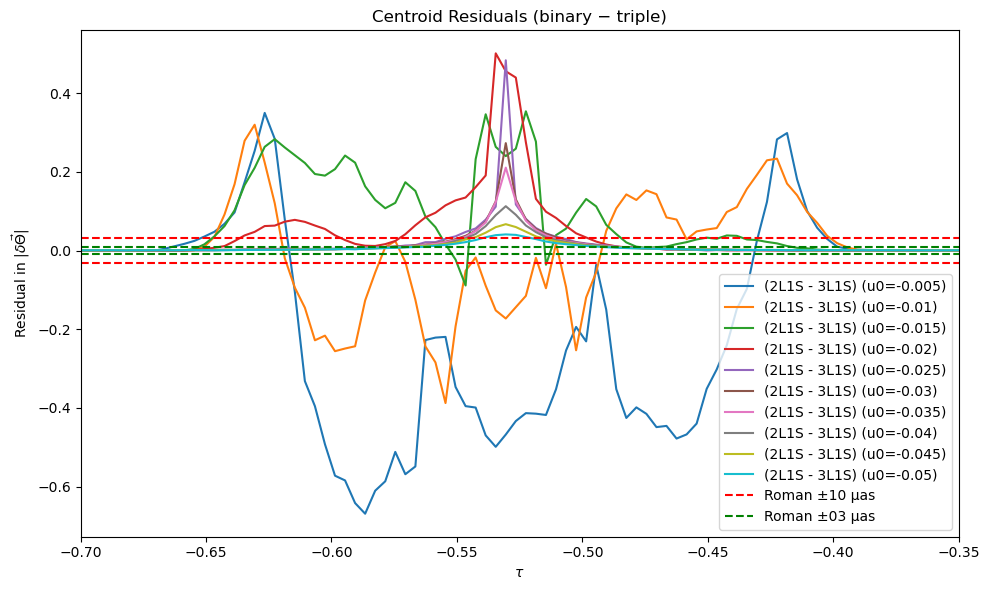

In [10]:
# 3) Residuals vs τ with Roman sensitivity bands
plt.figure(figsize=(10,6))
for u0, R in results.items():
    plt.plot(R['tau'], R['res'], label=fr'(2L1S - 3L1S) (u0={u0:g})')
plt.axhline( roman_sensitivity, linestyle='--', label="Roman ±10 µas", color='red')
plt.axhline(-roman_sensitivity, linestyle='--', color='red')

plt.axhline( roman_sensitivity_3, linestyle='--', label="Roman ±03 µas", color='green')
plt.axhline(-roman_sensitivity_3, linestyle='--', color='green')

plt.xlim(-0.7, -0.35)
plt.xlabel(r'$\tau$')
plt.ylabel(r"Residual in $|\delta \vec{\Theta}|$")
plt.title('Centroid Residuals (binary − triple)')
plt.legend()
plt.tight_layout()
plt.show()

# Checking Individual U0

### u0 = 0.040

u0=-0.04 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.04 0.04 0.04 0.04 0.04]
u0=-0.04 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.04 0.04 0.04 0.04 0.04]


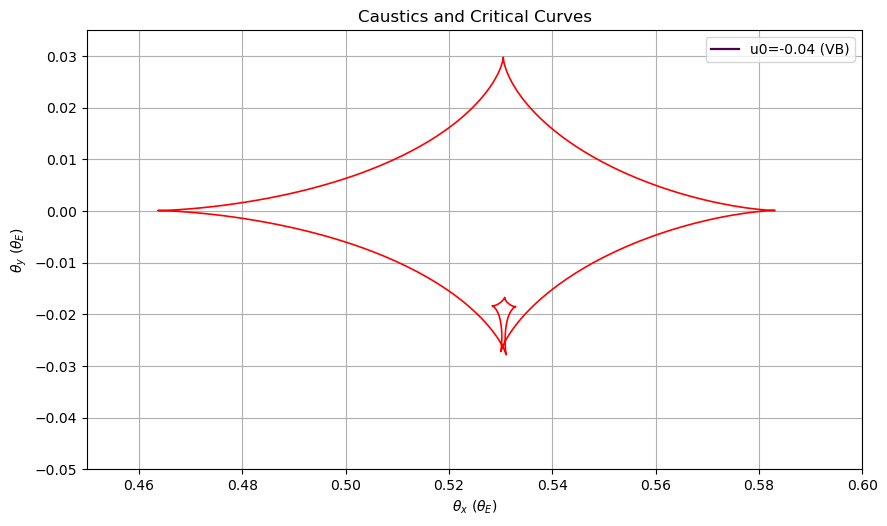

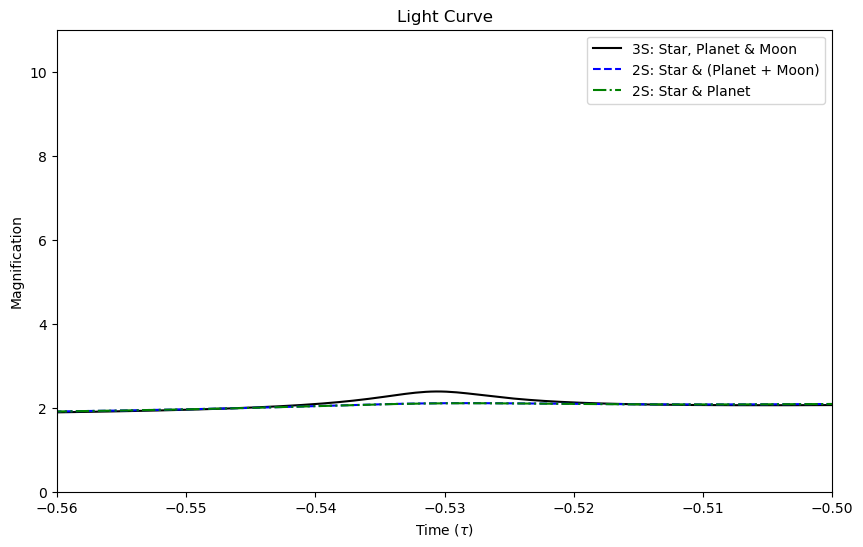

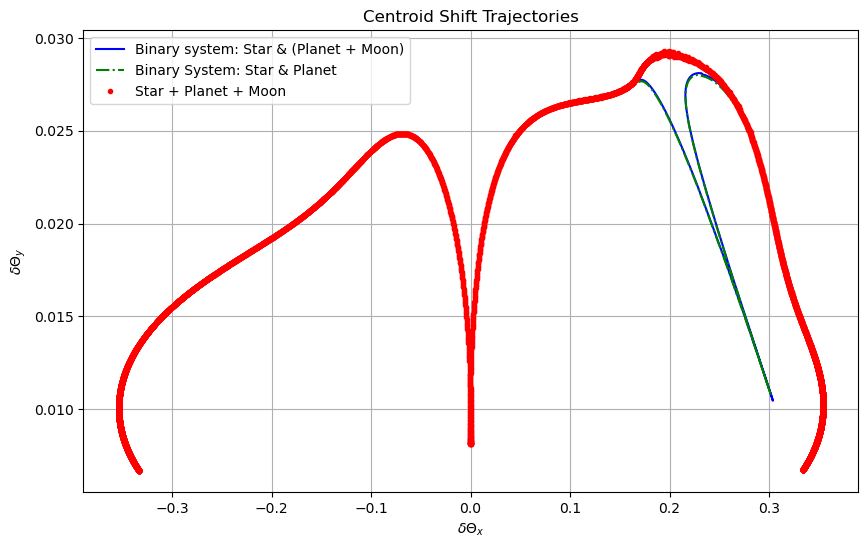

In [11]:
#trinary system
triple_model_04 = ThreeLens1S(t0, tE, rho, [-0.04], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 10000)

param = [
    np.log(triple_model_04.s2), np.log(triple_model_04.q2), triple_model_04.u0_list[0], triple_model_04.alpha_deg,
    np.log(triple_model_04.rho), np.log(triple_model_04.tE), triple_model_04.t0,
    np.log(triple_model_04.s3), np.log(triple_model_04.q3), triple_model_04.psi_rad
]
mag_04, *_ = triple_model_04.VBM.TripleLightCurve(param, triple_model_04.highres_t)

triple_model_tau_04 = triple_model_04.highres_tau
triple_model_mag_04 = mag_04

#binary system
double_model_04 = TwoLens1S(t0, tE, rho, [-0.04], q4, s2, 0, t_lc= triple_model_04.highres_t )
A_bin_04 = double_model_04.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_04.highres_t)[0]

binary_model_04 = TwoLens1S(t0, tE, rho, [-0.04], q2, s2, 0, t_lc= triple_model_04.highres_t )
B_bin_04 = binary_model_04.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_04.highres_t)[0]

#plot caustic & critical curves
triple_model_04.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_04.highres_tau, triple_model_mag_04, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_04, A_bin_04, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_04, B_bin_04, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_04    = double_model_04.systems[0]
binary_system_04 = binary_model_04.systems[0]
three_system_04  = triple_model_04.systems[0]

# 2L1S 
delta_x_two_04 = two_system_04['cent_x_lc'] - two_system_04['y1s_lc']
delta_y_two_04 = two_system_04['cent_y_lc'] - two_system_04['y2s_lc']

delta_x_two_B_04 = binary_system_04['cent_x_lc'] - binary_system_04['y1s_lc']
delta_y_two_B_04 = binary_system_04['cent_y_lc'] - binary_system_04['y2s_lc']

# 3L1S 
delta_x_three_04 = three_system_04['cent_x'] - three_system_04['y1s']
delta_y_three_04 = three_system_04['cent_y'] - three_system_04['y2s']

delta_x_three_04 = delta_x_three_04
delta_y_three_04 = -delta_y_three_04

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_04, delta_y_two_04, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_04, delta_y_two_B_04, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_04, delta_y_three_04, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_04, delta_y_three_04, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

### u0 = 0.035

u0=-0.035 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.035 0.035 0.035 0.035 0.035]
u0=-0.035 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.035 0.035 0.035 0.035 0.035]


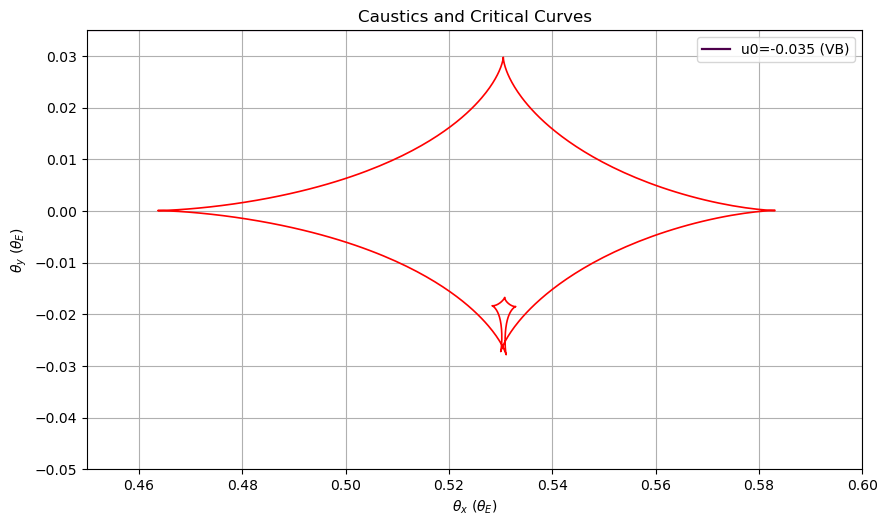

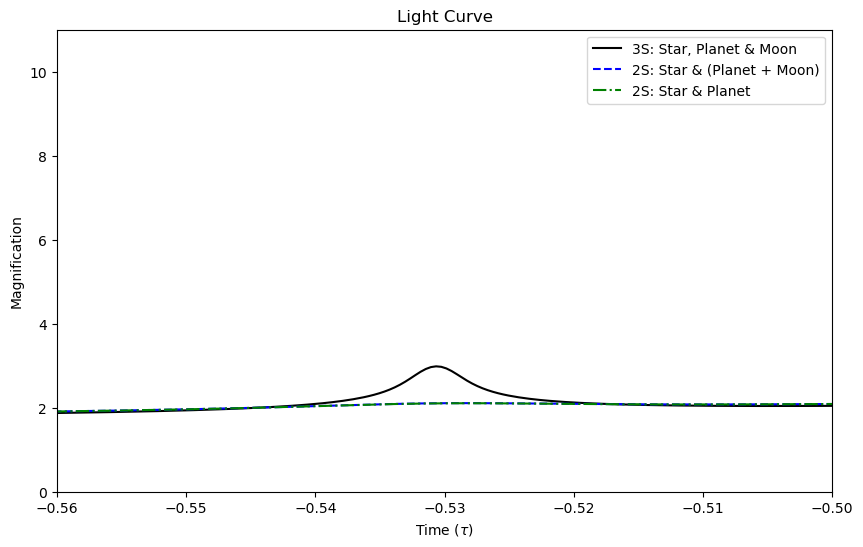

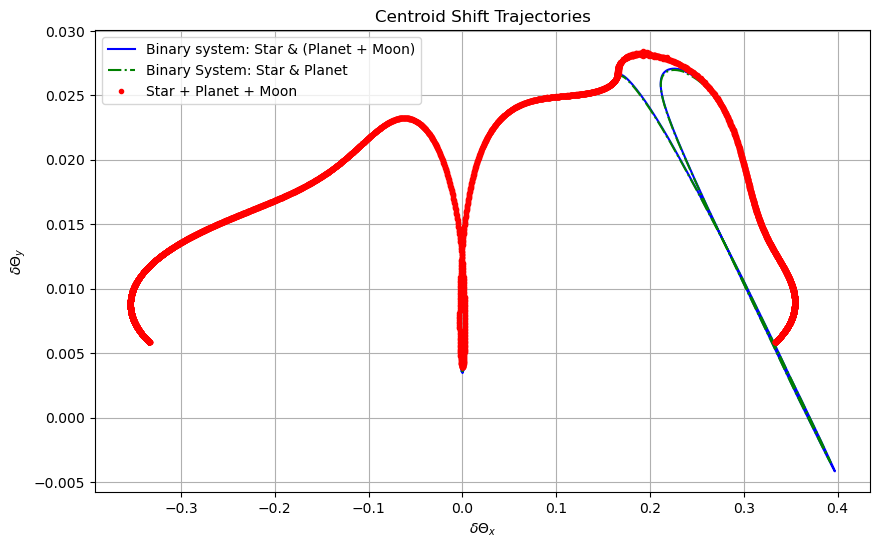

In [12]:
#trinary system
triple_model_035 = ThreeLens1S(t0, tE, rho, [-0.035], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 10000)

param = [
    np.log(triple_model_035.s2), np.log(triple_model_035.q2), triple_model_035.u0_list[0], triple_model_035.alpha_deg,
    np.log(triple_model_035.rho), np.log(triple_model_035.tE), triple_model_035.t0,
    np.log(triple_model_035.s3), np.log(triple_model_035.q3), triple_model_035.psi_rad
]
mag_035, *_ = triple_model_035.VBM.TripleLightCurve(param, triple_model_035.highres_t)

triple_model_tau_035 = triple_model_035.highres_tau
triple_model_mag_035 = mag_035

#binary system
double_model_035 = TwoLens1S(t0, tE, rho, [-0.035], q4, s2, 0, t_lc= triple_model_035.highres_t )
A_bin_035 = double_model_035.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_035.highres_t)[0]

binary_model_035 = TwoLens1S(t0, tE, rho, [-0.035], q2, s2, 0, t_lc= triple_model_035.highres_t )
B_bin_035 = binary_model_035.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_035.highres_t)[0]

#plot caustic & critical curves
triple_model_035.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_035.highres_tau, triple_model_mag_035, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_035, A_bin_035, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_035, B_bin_035, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_035   = double_model_035.systems[0]
binary_system_035 = binary_model_035.systems[0]
three_system_035  = triple_model_035.systems[0]

# 2L1S 
delta_x_two_035 = two_system_035['cent_x_lc'] - two_system_035['y1s_lc']
delta_y_two_035 = two_system_035['cent_y_lc'] - two_system_035['y2s_lc']

delta_x_two_B_035 = binary_system_035['cent_x_lc'] - binary_system_035['y1s_lc']
delta_y_two_B_035 = binary_system_035['cent_y_lc'] - binary_system_035['y2s_lc']

# 3L1S 
delta_x_three_035 = three_system_035['cent_x'] - three_system_035['y1s']
delta_y_three_035 = three_system_035['cent_y'] - three_system_035['y2s']

delta_x_three_035 = delta_x_three_035
delta_y_three_035 = -delta_y_three_035

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_035, delta_y_two_035, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_035, delta_y_two_B_035, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_035, delta_y_three_035, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_035, delta_y_three_035, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

### u0 = 0.030

u0=-0.03 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.03 0.03 0.03 0.03 0.03]
u0=-0.03 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.03 0.03 0.03 0.03 0.03]


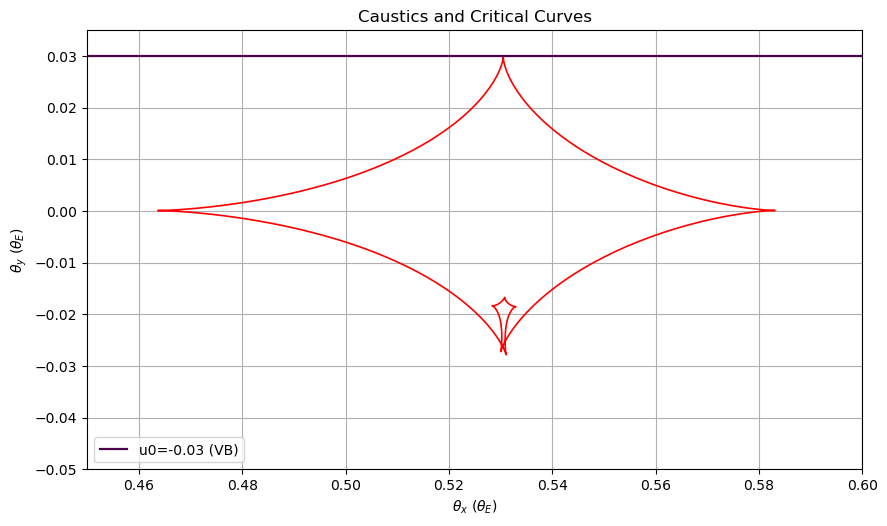

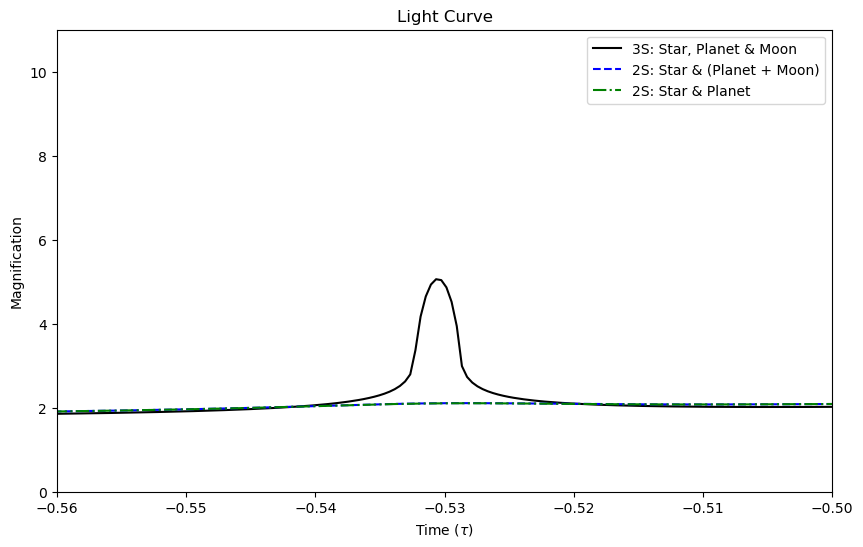

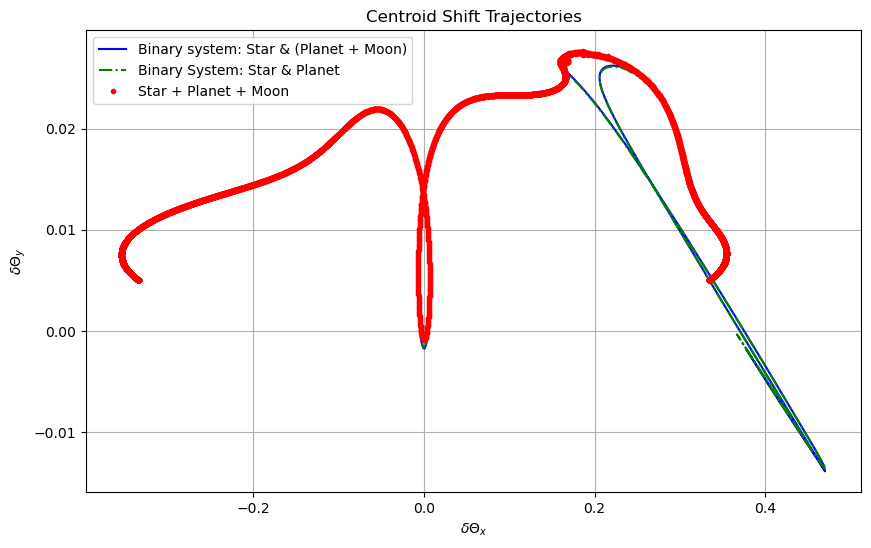

In [13]:
#trinary system
triple_model_03 = ThreeLens1S(t0, tE, rho, [-0.03], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 10000)

param = [
    np.log(triple_model_03.s2), np.log(triple_model_03.q2), triple_model_03.u0_list[0], triple_model_03.alpha_deg,
    np.log(triple_model_03.rho), np.log(triple_model_03.tE), triple_model_03.t0,
    np.log(triple_model_03.s3), np.log(triple_model_03.q3), triple_model_03.psi_rad
]
mag_03, *_ = triple_model_03.VBM.TripleLightCurve(param, triple_model_035.highres_t)

triple_model_tau_03 = triple_model_03.highres_tau
triple_model_mag_03 = mag_03

#binary system
double_model_03 = TwoLens1S(t0, tE, rho, [-0.03], q4, s2, 0, t_lc= triple_model_03.highres_t )
A_bin_03 = double_model_03.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_03.highres_t)[0]

binary_model_03 = TwoLens1S(t0, tE, rho, [-0.03], q2, s2, 0, t_lc= triple_model_03.highres_t )
B_bin_03 = binary_model_03.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_03.highres_t)[0]

#plot caustic & critical curves
triple_model_03.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_03.highres_tau, triple_model_mag_03, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_03, A_bin_03, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_03, B_bin_03, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_03   = double_model_03.systems[0]
binary_system_03 = binary_model_03.systems[0]
three_system_03 = triple_model_03.systems[0]

# 2L1S 
delta_x_two_03 = two_system_03['cent_x_lc'] - two_system_03['y1s_lc']
delta_y_two_03 = two_system_03['cent_y_lc'] - two_system_03['y2s_lc']

delta_x_two_B_03 = binary_system_03['cent_x_lc'] - binary_system_03['y1s_lc']
delta_y_two_B_03 = binary_system_03['cent_y_lc'] - binary_system_03['y2s_lc']

# 3L1S 
delta_x_three_03 = three_system_03['cent_x'] - three_system_03['y1s']
delta_y_three_03 = three_system_03['cent_y'] - three_system_03['y2s']

delta_x_three_03 = delta_x_three_03
delta_y_three_03 = -delta_y_three_03

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_03, delta_y_two_03, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_03, delta_y_two_B_03, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_03, delta_y_three_03, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_03, delta_y_three_03, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

### u0 = 0.025

u0=-0.025 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.025 0.025 0.025 0.025 0.025]
u0=-0.025 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.025 0.025 0.025 0.025 0.025]


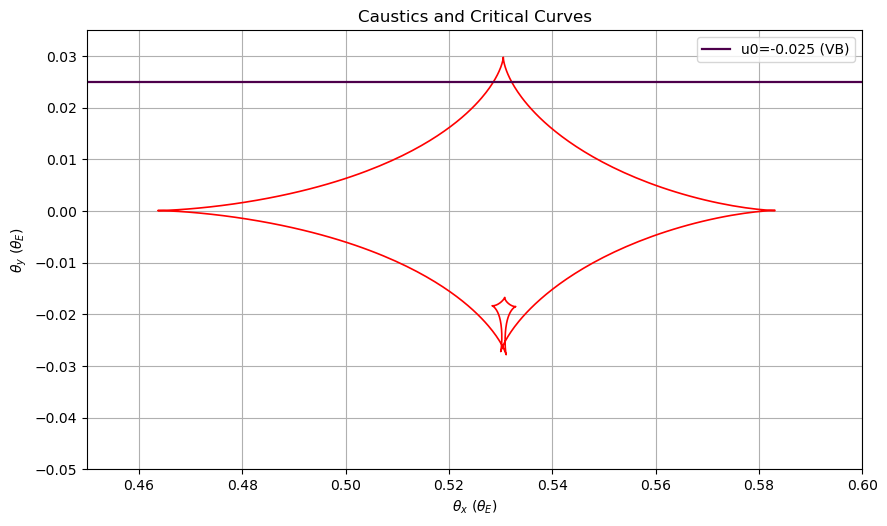

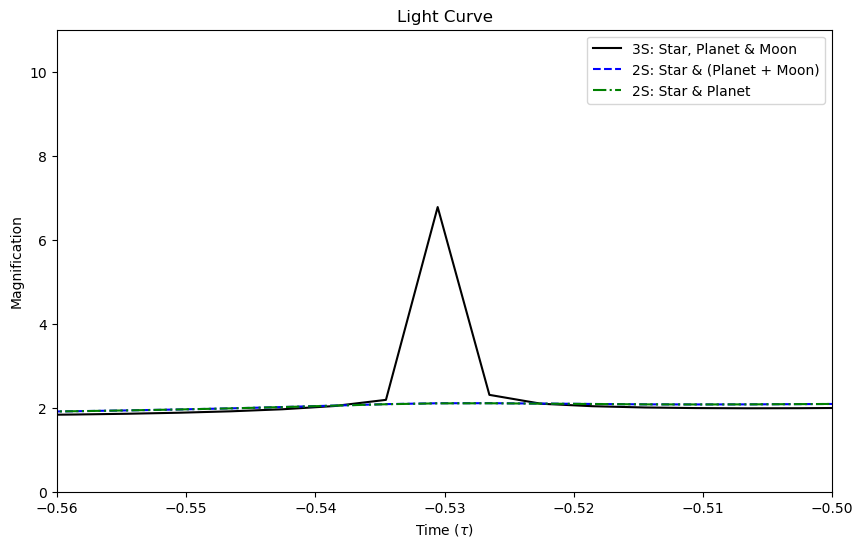

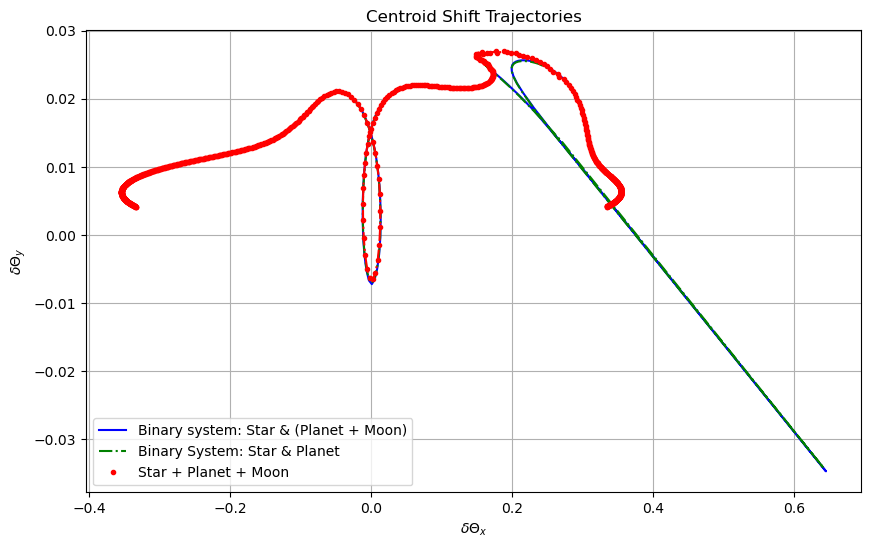

In [14]:
#trinary system
triple_model_025 = ThreeLens1S(t0, tE, rho, [-0.025], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 1000)

param = [
    np.log(triple_model_025.s2), np.log(triple_model_025.q2), triple_model_025.u0_list[0], triple_model_025.alpha_deg,
    np.log(triple_model_025.rho), np.log(triple_model_025.tE), triple_model_025.t0,
    np.log(triple_model_025.s3), np.log(triple_model_025.q3), triple_model_025.psi_rad
]
mag_025, *_ = triple_model_025.VBM.TripleLightCurve(param, triple_model_025.highres_t)

triple_model_tau_025 = triple_model_025.highres_tau
triple_model_mag_025 = mag_025

#binary system
double_model_025 = TwoLens1S(t0, tE, rho, [-0.025], q4, s2, 0, t_lc= triple_model_025.highres_t )
A_bin_025 = double_model_025.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_025.highres_t)[0]

binary_model_025 = TwoLens1S(t0, tE, rho, [-0.025], q2, s2, 0, t_lc= triple_model_025.highres_t )
B_bin_025 = binary_model_025.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_025.highres_t)[0]

#plot caustic & critical curves
triple_model_025.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_025.highres_tau, triple_model_mag_025, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_025, A_bin_025, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_025, B_bin_025, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_025   = double_model_025.systems[0]
binary_system_025 = binary_model_025.systems[0]
three_system_025  = triple_model_025.systems[0]

# 2L1S 
delta_x_two_025 = two_system_025['cent_x_lc'] - two_system_025['y1s_lc']
delta_y_two_025 = two_system_025['cent_y_lc'] - two_system_025['y2s_lc']

delta_x_two_B_025 = binary_system_025['cent_x_lc'] - binary_system_025['y1s_lc']
delta_y_two_B_025 = binary_system_025['cent_y_lc'] - binary_system_025['y2s_lc']

# 3L1S 
delta_x_three_025 = three_system_025['cent_x'] - three_system_025['y1s']
delta_y_three_025 = three_system_025['cent_y'] - three_system_025['y2s']

delta_x_three_025 = delta_x_three_025
delta_y_three_025 = -delta_y_three_025

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_025, delta_y_two_025, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_025, delta_y_two_B_025, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_025, delta_y_three_025, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_025, delta_y_three_025, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

### u0 = 0.020

u0=-0.02 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.02 0.02 0.02 0.02 0.02]
u0=-0.02 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.02 0.02 0.02 0.02 0.02]


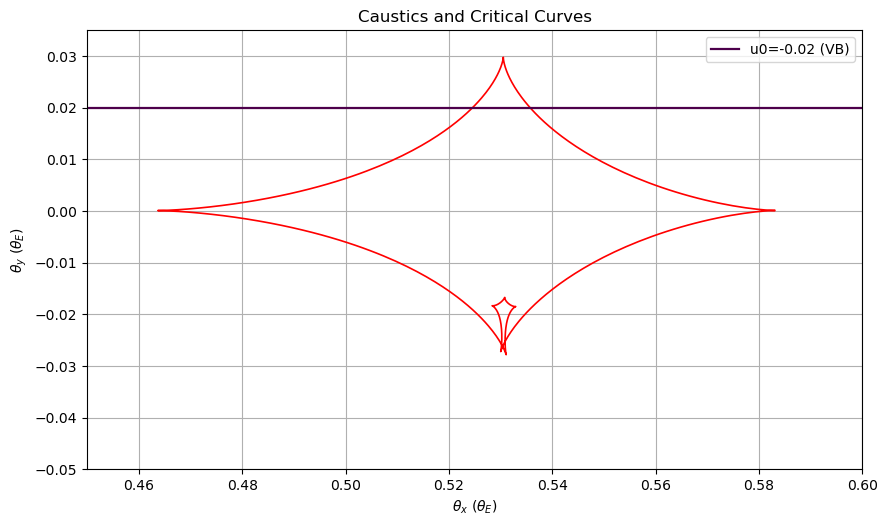

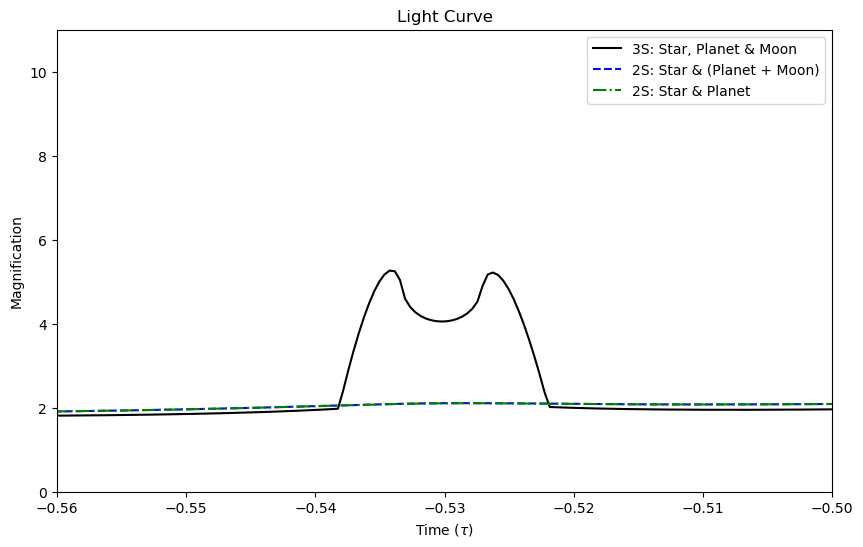

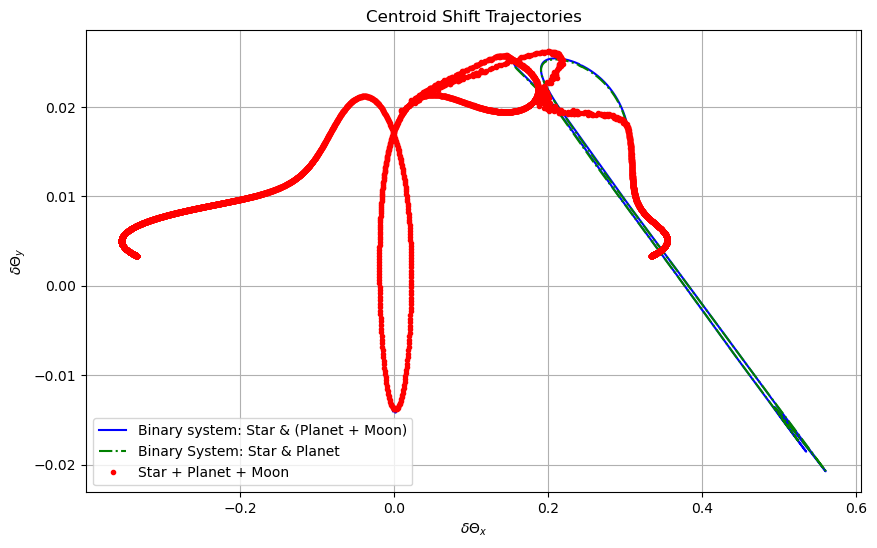

In [15]:
#trinary system
triple_model_020 = ThreeLens1S(t0, tE, rho, [-0.020], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 10000)

param = [
    np.log(triple_model_020.s2), np.log(triple_model_020.q2), triple_model_020.u0_list[0], triple_model_020.alpha_deg,
    np.log(triple_model_020.rho), np.log(triple_model_020.tE), triple_model_020.t0,
    np.log(triple_model_020.s3), np.log(triple_model_020.q3), triple_model_020.psi_rad
]
mag_020, *_ = triple_model_020.VBM.TripleLightCurve(param, triple_model_020.highres_t)

triple_model_tau_020 = triple_model_020.highres_tau
triple_model_mag_020 = mag_020

#binary system
double_model_020 = TwoLens1S(t0, tE, rho, [-0.020], q4, s2, 0, t_lc= triple_model_020.highres_t )
A_bin_020 = double_model_020.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_020.highres_t)[0]

binary_model_020 = TwoLens1S(t0, tE, rho, [-0.020], q2, s2, 0, t_lc= triple_model_020.highres_t )
B_bin_020 = binary_model_020.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_020.highres_t)[0]

#plot caustic & critical curves
triple_model_020.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_020.highres_tau, triple_model_mag_020, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_020, A_bin_020, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_020, B_bin_020, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_020   = double_model_020.systems[0]
binary_system_020 = binary_model_020.systems[0]
three_system_020  = triple_model_020.systems[0]

# 2L1S 
delta_x_two_020 = two_system_020['cent_x_lc'] - two_system_020['y1s_lc']
delta_y_two_020 = two_system_020['cent_y_lc'] - two_system_020['y2s_lc']

delta_x_two_B_020 = binary_system_020['cent_x_lc'] - binary_system_020['y1s_lc']
delta_y_two_B_020 = binary_system_020['cent_y_lc'] - binary_system_020['y2s_lc']

# 3L1S 
delta_x_three_020 = three_system_020['cent_x'] - three_system_020['y1s']
delta_y_three_020 = three_system_020['cent_y'] - three_system_020['y2s']

delta_x_three_020 = delta_x_three_020
delta_y_three_020 = -delta_y_three_020

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_020, delta_y_two_020, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_020, delta_y_two_B_020, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_020, delta_y_three_020, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_020, delta_y_three_020, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

### u0 = 0.015

u0=-0.015 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.015 0.015 0.015 0.015 0.015]
u0=-0.015 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.015 0.015 0.015 0.015 0.015]


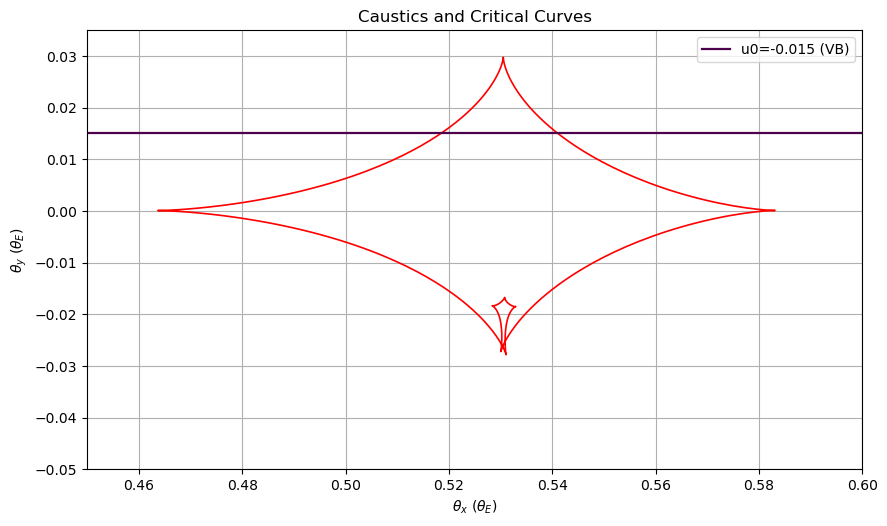

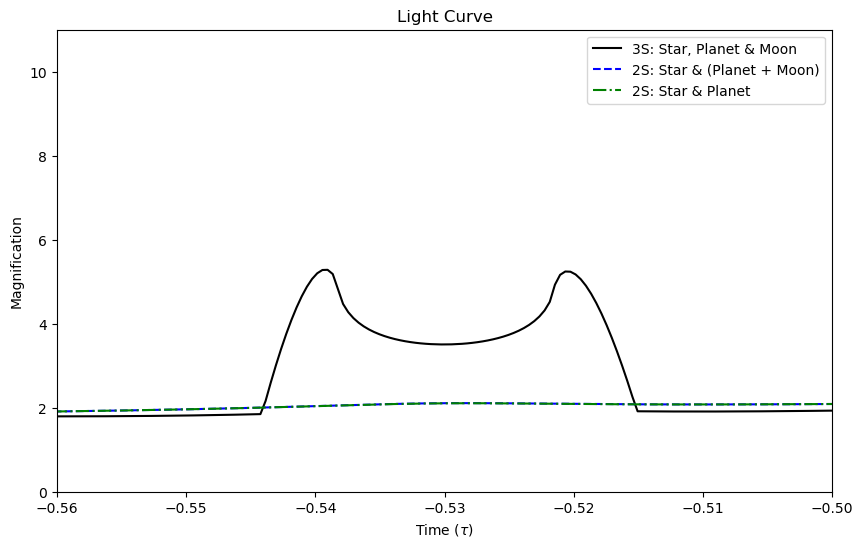

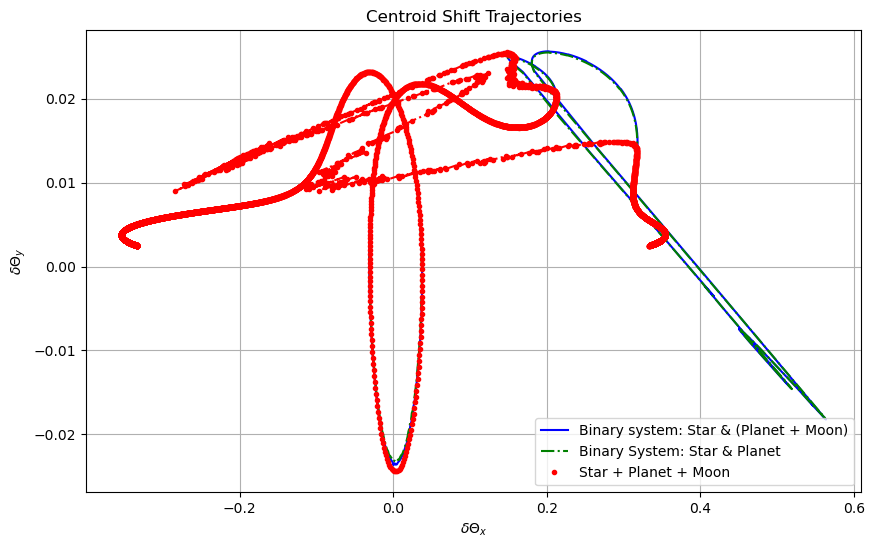

In [16]:
#trinary system
triple_model_015 = ThreeLens1S(t0, tE, rho, [-0.015], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 10000)

param = [
    np.log(triple_model_015.s2), np.log(triple_model_015.q2), triple_model_015.u0_list[0], triple_model_015.alpha_deg,
    np.log(triple_model_015.rho), np.log(triple_model_015.tE), triple_model_015.t0,
    np.log(triple_model_015.s3), np.log(triple_model_015.q3), triple_model_015.psi_rad
]
mag_015, *_ = triple_model_015.VBM.TripleLightCurve(param, triple_model_015.highres_t)

triple_model_tau_015 = triple_model_015.highres_tau
triple_model_mag_015 = mag_015

#binary system
double_model_015 = TwoLens1S(t0, tE, rho, [-0.015], q4, s2, 0, t_lc= triple_model_015.highres_t )
A_bin_015 = double_model_015.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_015.highres_t)[0]

binary_model_015 = TwoLens1S(t0, tE, rho, [-0.015], q2, s2, 0, t_lc= triple_model_015.highres_t )
B_bin_015 = binary_model_015.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_015.highres_t)[0]

#plot caustic & critical curves
triple_model_015.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_015.highres_tau, triple_model_mag_015, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_015, A_bin_015, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_015, B_bin_015, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_015   = double_model_015.systems[0]
binary_system_015 = binary_model_015.systems[0]
three_system_015  = triple_model_015.systems[0]

# 2L1S 
delta_x_two_015 = two_system_015['cent_x_lc'] - two_system_015['y1s_lc']
delta_y_two_015 = two_system_015['cent_y_lc'] - two_system_015['y2s_lc']

delta_x_two_B_015 = binary_system_015['cent_x_lc'] - binary_system_015['y1s_lc']
delta_y_two_B_015 = binary_system_015['cent_y_lc'] - binary_system_015['y2s_lc']

# 3L1S 
delta_x_three_015 = three_system_015['cent_x'] - three_system_015['y1s']
delta_y_three_015 = three_system_015['cent_y'] - three_system_015['y2s']

delta_x_three_015 = delta_x_three_015
delta_y_three_015 = -delta_y_three_015

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_015, delta_y_two_015, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_015, delta_y_two_B_015, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_015, delta_y_three_015, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_015, delta_y_three_015, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

### u0 = 0.010

u0=-0.015 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.015 0.015 0.015 0.015 0.015]
u0=-0.015 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.015 0.015 0.015 0.015 0.015]


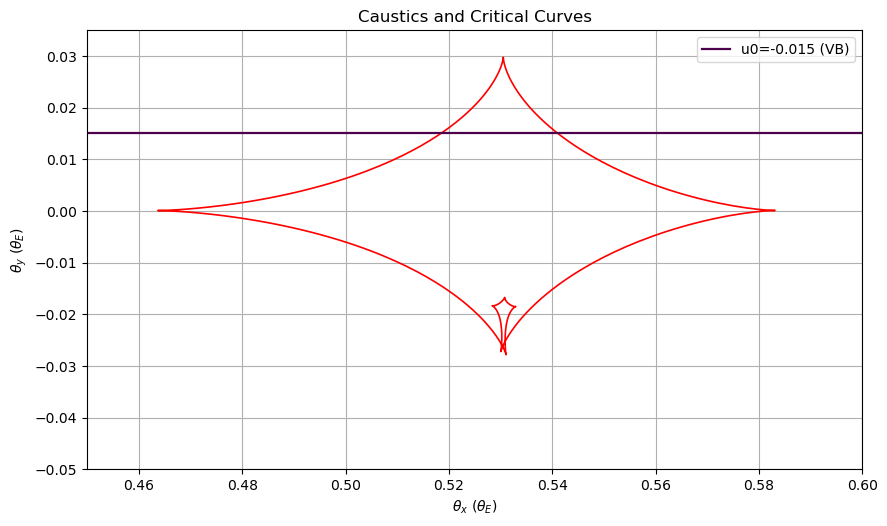

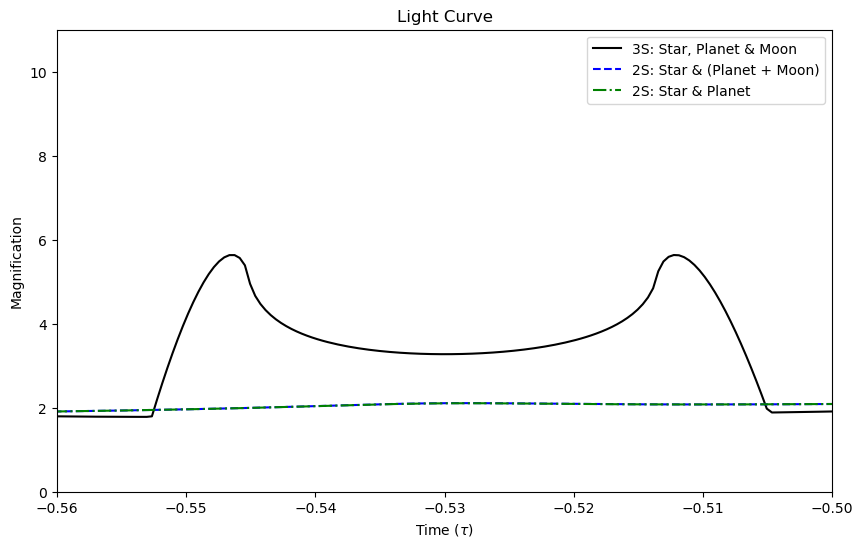

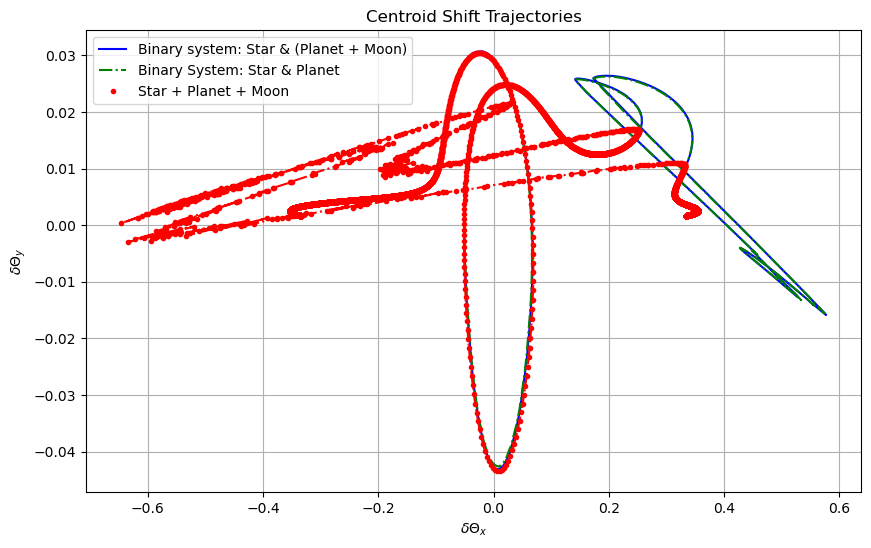

In [17]:
#trinary system
triple_model_01 = ThreeLens1S(t0, tE, rho, [-0.01], q2, q3, s2, s3, 0, psi, rs, secnum, basenum, 10000)

param = [
    np.log(triple_model_01.s2), np.log(triple_model_01.q2), triple_model_01.u0_list[0], triple_model_01.alpha_deg,
    np.log(triple_model_01.rho), np.log(triple_model_01.tE), triple_model_01.t0,
    np.log(triple_model_01.s3), np.log(triple_model_01.q3), triple_model_01.psi_rad
]
mag_01, *_ = triple_model_01.VBM.TripleLightCurve(param, triple_model_01.highres_t)

triple_model_tau_01 = triple_model_01.highres_tau
triple_model_mag_01 = mag_01

#binary system
double_model_01 = TwoLens1S(t0, tE, rho, [-0.01], q4, s2, 0, t_lc= triple_model_01.highres_t )
A_bin_01 = double_model_01.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_01.highres_t)[0]

binary_model_01 = TwoLens1S(t0, tE, rho, [-0.01], q2, s2, 0, t_lc= triple_model_01.highres_t )
B_bin_01 = binary_model_01.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model_01.highres_t)[0]

#plot caustic & critical curves
triple_model_015.plot_caustics_and_critical(show = False)

ax = plt.gca()

ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model_01.highres_tau, triple_model_mag_01, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau_01, A_bin_01, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau_01, B_bin_01, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

#Setting Up Centroids
two_system_01   = double_model_01.systems[0]
binary_system_01 = binary_model_01.systems[0]
three_system_01  = triple_model_01.systems[0]

# 2L1S 
delta_x_two_01 = two_system_01['cent_x_lc'] - two_system_01['y1s_lc']
delta_y_two_01 = two_system_01['cent_y_lc'] - two_system_01['y2s_lc']

delta_x_two_B_01 = binary_system_01['cent_x_lc'] - binary_system_01['y1s_lc']
delta_y_two_B_01 = binary_system_01['cent_y_lc'] - binary_system_01['y2s_lc']

# 3L1S 
delta_x_three_01 = three_system_01['cent_x'] - three_system_01['y1s']
delta_y_three_01 = three_system_01['cent_y'] - three_system_01['y2s']

delta_x_three_01 = delta_x_three_01
delta_y_three_01 = -delta_y_three_01

#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two_01, delta_y_two_01, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B_01, delta_y_two_B_01, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three_01, delta_y_three_01, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three_01, delta_y_three_01, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()